# **Import Libraries**

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# **Load Dataset**

In [7]:
from google.colab import files
uploaded = files.upload()

Saving Iris.csv to Iris.csv


In [8]:
df = pd.read_csv("Iris.csv")

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


# **Explore Dataset**
**Shape**

In [9]:
df.shape

(150, 6)

# **Information**

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


# **Statistics**

In [12]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


# **Check Missing Values**

In [13]:
df.isnull().sum()

,0
Id,0
SepalLengthCm,0
SepalWidthCm,0
PetalLengthCm,0
PetalWidthCm,0
Species,0


# **Check Class Distribution**

In [14]:
df["Species"].value_counts()

,count
Species,
Iris-setosa,50
Iris-versicolor,50
Iris-virginica,50


# **Drop Unnecessary Column**

In [15]:
df = df.drop("Id", axis=1)

# **Separate Features and Target**

In [16]:
X = df.drop("Species", axis=1)

y = df["Species"]

# **Split Dataset**

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# **Train Model**

In [18]:
model = DecisionTreeClassifier(random_state=42)

model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

# **Prediction**

In [19]:
y_pred = model.predict(X_test)

# **Accuracy**

In [20]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 1.0


# **Confusion Matrix**

In [22]:
cm = confusion_matrix(y_test, y_pred)

print(cm)


[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


# **Classification Report**

In [23]:
print(classification_report(y_test, y_pred))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



# **Predict a New Flower**

In [24]:
sample = [[5.1, 3.5, 1.4, 0.2]]

prediction = model.predict(sample)

print("Predicted Species:", prediction[0])

Predicted Species: Iris-setosa


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


# **Visualize the Decision Tree**

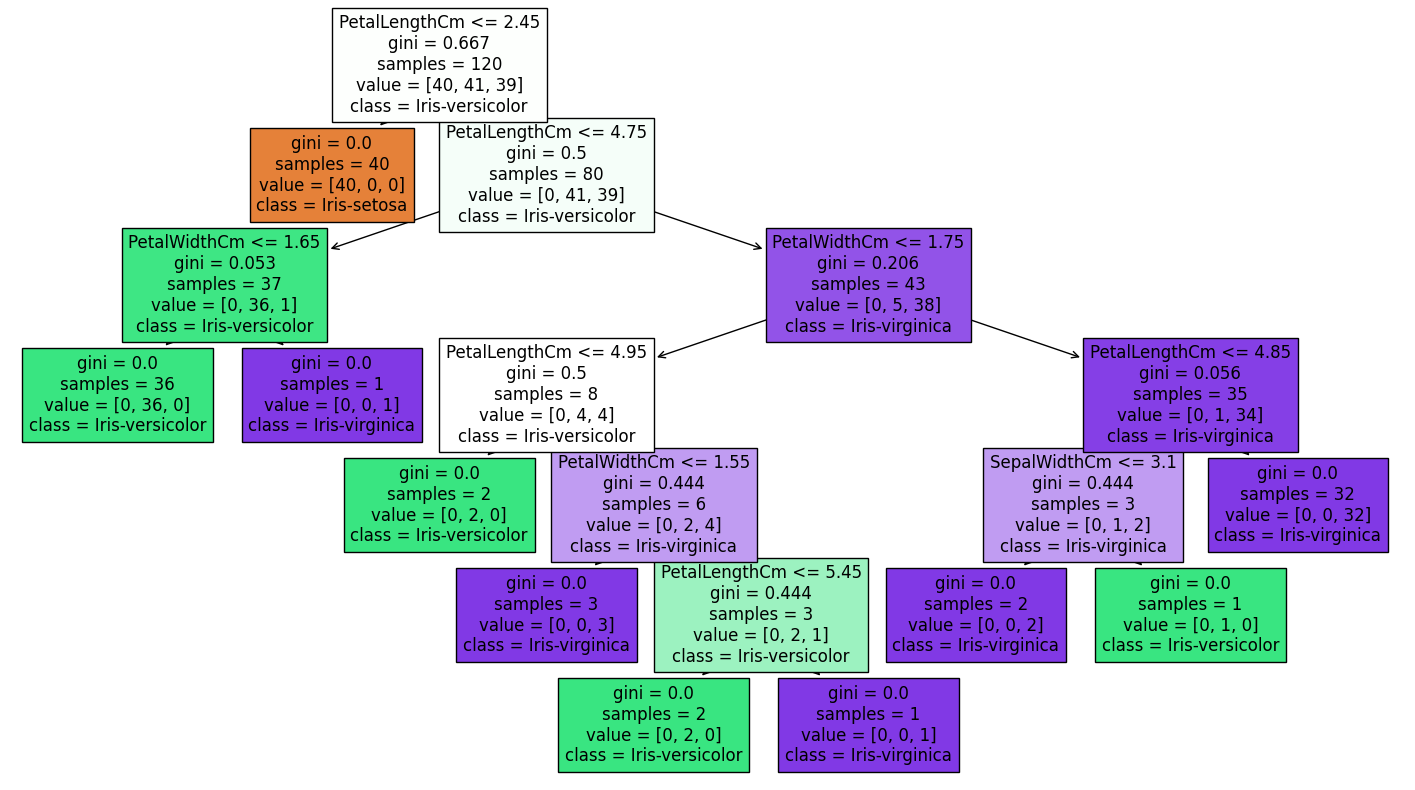

In [25]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18,10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=model.classes_,
    filled=True
)

plt.show()

# **Save the Model**

In [26]:
import joblib

joblib.dump(model, "iris_model.pkl")

['iris_model.pkl']

# **Conclusion**

In this project, a Decision Tree Classifier was used to classify Iris flowers into three species: Iris-setosa, Iris-versicolor, and Iris-virginica. The dataset contained 150 samples with four flower measurements as input features. After training and testing the model, it achieved high accuracy, demonstrating that machine learning can effectively classify Iris flower species.